# Feature Engineering part 3 - Feature Selection

In [1]:
PROJECT_DIR = ".."
DATA_DIR = f"{PROJECT_DIR}/data"
ARTIFACTS_DIR = PROJECT_DIR
SEED = 42

## Model

The model hyperparameters for were chosen on the early iterations of this project, starting with values that looked reasonable and making some
adjustments. No rigorous hyperparameter search was performed, that could be a future improvement.

The purpose of *scale_pos_weight* is to compensate for target class imbalance. Our target has a positive class ratio of approximately 0.08. The first
attempt was to set the parameter to the negative-to-positive class ratio, which is approximately $(1-0.08)/0.08 = 11.5$. Then the square root of that
value was used, which seemed to work better, and is approximately the value used here.

It's worth mentioning that the XGBoost builtin support for categorical features is being used here (parameter enable_categorical=True). It's assumed
that all categorical columns on the dataframes used to fit the model are of the type 'category'. The data_util.load_data() function was implemented
to ensure that when reading the data.

In [12]:
import xgboost as xgb

def create_model():
    return xgb.XGBClassifier(
        tree_method="hist",
        objective='binary:logistic',
        enable_categorical=True,
        random_state=SEED,
        scale_pos_weight=3.5,
        n_estimators=700,
        max_depth=5,
        eta=0.05,
        gamma=5,
        min_child_weight=5,
        subsample=0.5,
        reg_lambda=50,
        alpha=50,
    )

## Dataset

In [4]:
import pandas as pd
import home_credit_risk.features as ft
import home_credit_risk.data_util as data_util

# Loads the generated features, reduced by feature clustering with 1500 clusters
gen_features_base_file_path = f"{DATA_DIR}/generated_features_1500"
gen_features_train_df = pd.read_csv(f"{gen_features_base_file_path}_train.csv",
                                    index_col=data_util.APP_ID_COL)


x_train = data_util.load_table(f"{DATA_DIR}/application_train.csv")
# Keep the ids as the index, we'll need them in the end
x_train.set_index(data_util.APP_ID_COL, inplace=True)
x_train = ft.merge_features(x_train, gen_features_train_df)
gen_features_train_df = None

y_train = x_train[data_util.TARGET_COL]
# No need to drop the id column, as it was set to be the index
x_train = x_train.drop(columns=[data_util.TARGET_COL])
print(f"Training dataset shape = {x_train.shape}")

Training dataset shape = (307511, 1620)


## Cross Validation

In [13]:
import numpy as np
import home_credit_risk.learning as learn

def cross_validate(features: list[str] = None):
  print(f"\nCross validating with {len(features) if features is not None else "all"} features")

  cv_result = learn.cross_validate_xgboost_model(
      model=create_model(),
      X=x_train if features is None else x_train[features],
      y=y_train,
      random_state=SEED,
      n_folds=5,
      n_jobs=5
  )

  test_scores = cv_result['test_score']
  train_scores = cv_result['train_score']
  print(f"\nTest scores: {test_scores}")
  print(f"Train scores: {train_scores}")
  mean_test_score = np.mean(test_scores)
  print(f"\nMean scores:  test = {mean_test_score:.5f} , train = {np.mean(train_scores):.5f}")
  print(f"Scores stds:  test = {np.std(test_scores):.5f} , train = {np.std(train_scores):.5f}")

  return mean_test_score, cv_result['xgb_total_gain']

# Only features with importance > 0 are included in the returned importance_map
score_all_features, importance_map = cross_validate()
n_non_zero_importance = len(importance_map)
print(f"\nNumber of non-zero importance features = {n_non_zero_importance}")


Cross validating with all features

Test scores: [0.79154583 0.79938227 0.7908845  0.79473934 0.78937932]
Train scores: [0.85358478 0.85153621 0.85386934 0.85246068 0.85276125]

Mean scores:  test = 0.79319 , train = 0.85284
Scores stds:  test = 0.00356 , train = 0.00083

Number of non-zero importance features = 981


## Top Features

In [14]:
features, importances = zip(
    *sorted([(feat, imp) for feat, imp in importance_map.items()],
    key=lambda x: x[1],
    reverse=True
))
features = list(features)

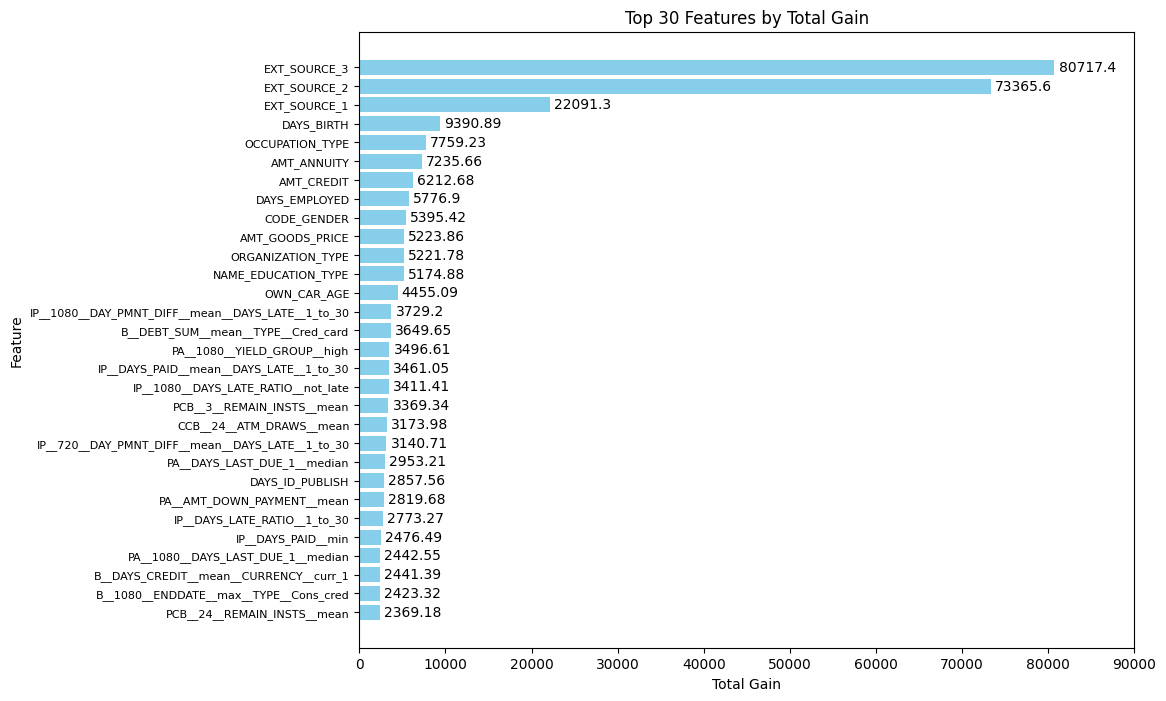

In [15]:
import matplotlib.pyplot as plt

n_feats = 30
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(features[0:n_feats], importances[0:n_feats], color='skyblue')
ax.invert_yaxis()
ax.grid(False, axis='y')
ax.set_ylabel('Feature')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlabel('Total Gain')
ax.set_xlim(right=90000)
ax.set_title(f'Top {n_feats} Features by Total Gain')
ax.bar_label(bars, padding=3)
plt.show()

## Fit Models for the Top N Features

In [18]:
import numpy as np
import home_credit_risk.learning as learn

print(f"\nLoading the test set...")
gen_features_test_df = pd.read_csv(f"{gen_features_base_file_path}_test.csv",
                                  index_col=data_util.APP_ID_COL)
x_test = data_util.load_table(f"{DATA_DIR}/application_test.csv")
x_test.set_index(data_util.APP_ID_COL, inplace=True)
x_test = ft.merge_features(x_test, gen_features_test_df)

best_features = features
best_score = score_all_features
# Try multiple numbers of top features
for t in range(100, n_non_zero_importance + 50, 50):
  top_features = features[0:t]
  n_top_features = len(top_features)

  score, _ = cross_validate(top_features)
  if score > best_score:
    best_score = score
    best_features = top_features

  # Fits the model to the full training set, for the top features
  x_train_reduced = x_train[top_features]
  model = create_model()
  print(f"\nFitting the model to the full training set with {n_top_features} features...")
  model.fit(x_train_reduced, y_train)
  model.save_model(f"{ARTIFACTS_DIR}/model/xgboost_model_{n_top_features}_v2.json")

  print(f"\nGenerating predictions on the test set for submission...")
  x_test_reduced = x_test[top_features]
  predictions = model.predict_proba(x_test_reduced)[:, 1]

  submission_df = pd.DataFrame({
      data_util.APP_ID_COL: x_test.index.values,
      data_util.TARGET_COL: predictions,
  })
  submission_file = f"{ARTIFACTS_DIR}/submissions/submission_{n_top_features}_v2.csv"
  print(f"Saving submission to {submission_file}")
  submission_df.to_csv(submission_file, index=False)

print(f"\nBest score is {best_score:.5f} for {len(best_features)} features")


Loading the test set...

Cross validating with 100 features

Test scores: [0.78910861 0.79711589 0.78855434 0.79126461 0.78749561]
Train scores: [0.84062664 0.83915741 0.84097475 0.8397961  0.84051534]

Mean scores:  test = 0.79071 , train = 0.84021
Scores stds:  test = 0.00343 , train = 0.00065

Fitting the model to the full training set with 100 features...

Generating predictions on the test set for submission...
Saving submission to /content/drive//MyDrive/home_credit_risk/submissions/submission_100_v2.csv

Cross validating with 150 features

Test scores: [0.79002486 0.79840946 0.7898627  0.79223299 0.7883921 ]
Train scores: [0.84570577 0.8438168  0.84595189 0.84507802 0.8455557 ]

Mean scores:  test = 0.79178 , train = 0.84522
Scores stds:  test = 0.00353 , train = 0.00076

Fitting the model to the full training set with 150 features...

Generating predictions on the test set for submission...
Saving submission to /content/drive//MyDrive/home_credit_risk/submissions/submission_15